In [1]:
import json
from test import test_model
import torch
from glob import glob
import random
import pandas as pd
from model import Encoder, Decoder
import torch.nn as nn
from monai.inferers import SlidingWindowInferer
import matplotlib.pyplot as plt
from easydict import EasyDict as edict
from dataset import get_dataloader

from monai.data import CacheDataset, DataLoader
from monai.transforms import (
    EnsureChannelFirstd,
    Compose,
    LoadImaged,
    ScaleIntensityRanged,
    EnsureTyped,
    Resized,
    RandSpatialCropd,
    SpatialPadd,
    Spacingd,
    ToDeviced,
    Orientationd,
    DeleteItemsd
)

from monai.data import ITKReader


mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-2ub7f7ki because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
MODEL_PATH = 'reports/ae_checkpoint_100.pth'
with open("config/train_no_sw.json", "r") as f:
    cfg = edict(json.load(f))

In [3]:
# Load model
checkpoint = torch.load(MODEL_PATH, weights_only=True)

encoder = Encoder(cfg.img_size[0], cfg.img_size[1], cfg.img_size[2], z_dim=512).to(cfg.device)
decoder = Decoder(cfg.img_size[0], cfg.img_size[1], cfg.img_size[2], z_dim=512).to(cfg.device)
encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])

<All keys matched successfully>

## Selecting images

In [4]:
deterministic_transforms = Compose(
    [
        LoadImaged(keys=["im"], image_only=False, reader=ITKReader(series_name="")),
        EnsureTyped(keys=["im"]),
        EnsureChannelFirstd(keys=["im"]),
        ToDeviced(keys=["im"], device = cfg.device),
        Orientationd(keys=["im"], axcodes="RAS"),
        ScaleIntensityRanged(
        keys=["im"],
        a_min=-15,
        a_max=85,
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),
        Spacingd(
            keys=["im"],
            pixdim=(1.0, 1.0, 1.0),
            mode="bilinear"
        ),
        Resized(keys = ['im'], spatial_size = (160,192,96)),
        DeleteItemsd(keys=["image_meta_dict"]),  # drop all metadata entirely
        
        
    ])

In [5]:
df = pd.read_csv(cfg.train_csv)
df = df[df['dataset_id'] == 'jpr_dados'][:1]
#df = df[df['Normal'] == False][:1]
filepaths = [{"im": fname} for fname in df['Path'][:cfg.n_images]]
filepaths = [{"im": p['im'].replace('D:/Backup/Mestrado/dados/', '/home/jovyan/imgs/').replace('\\', '/')} for p in filepaths]
filepaths = [{"im": p['im'].replace('D:/Mestrado/dados/', '/home/jovyan/imgs/').replace('\\', '/')} for p in filepaths]


train_transforms = Compose(deterministic_transforms.transforms)

#df[(df['dataset_id'] == 'jpr_dados') & (df['Sample'] == 'train')]



In [6]:
image = train_transforms(filepaths)
img_device = image[0]['im'].to(cfg.device)

builtin type SwigPyPacked has no __module__ attribute
builtin type SwigPyObject has no __module__ attribute
builtin type swigvarlink has no __module__ attribute


In [7]:
img_device = img_device.unsqueeze(0)

In [ ]:
z = encoder(img_device)
x_hat = decoder(z)

In [38]:
#train_loader = get_dataloader(cfg, mode="test")

In [39]:
# for data in train_loader:
#     img = data['im'].to(cfg.device)
#     # ==========forward=========
#     #z = encoder(img)
#     #x_hat = decoder(z)
#     break

## Visualize

Running smoke-test on: cuda


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Figure saved → prelim_results/recons_orig/slice_comparison.png
Done. Figure written to /tmp/slice_comparison.png


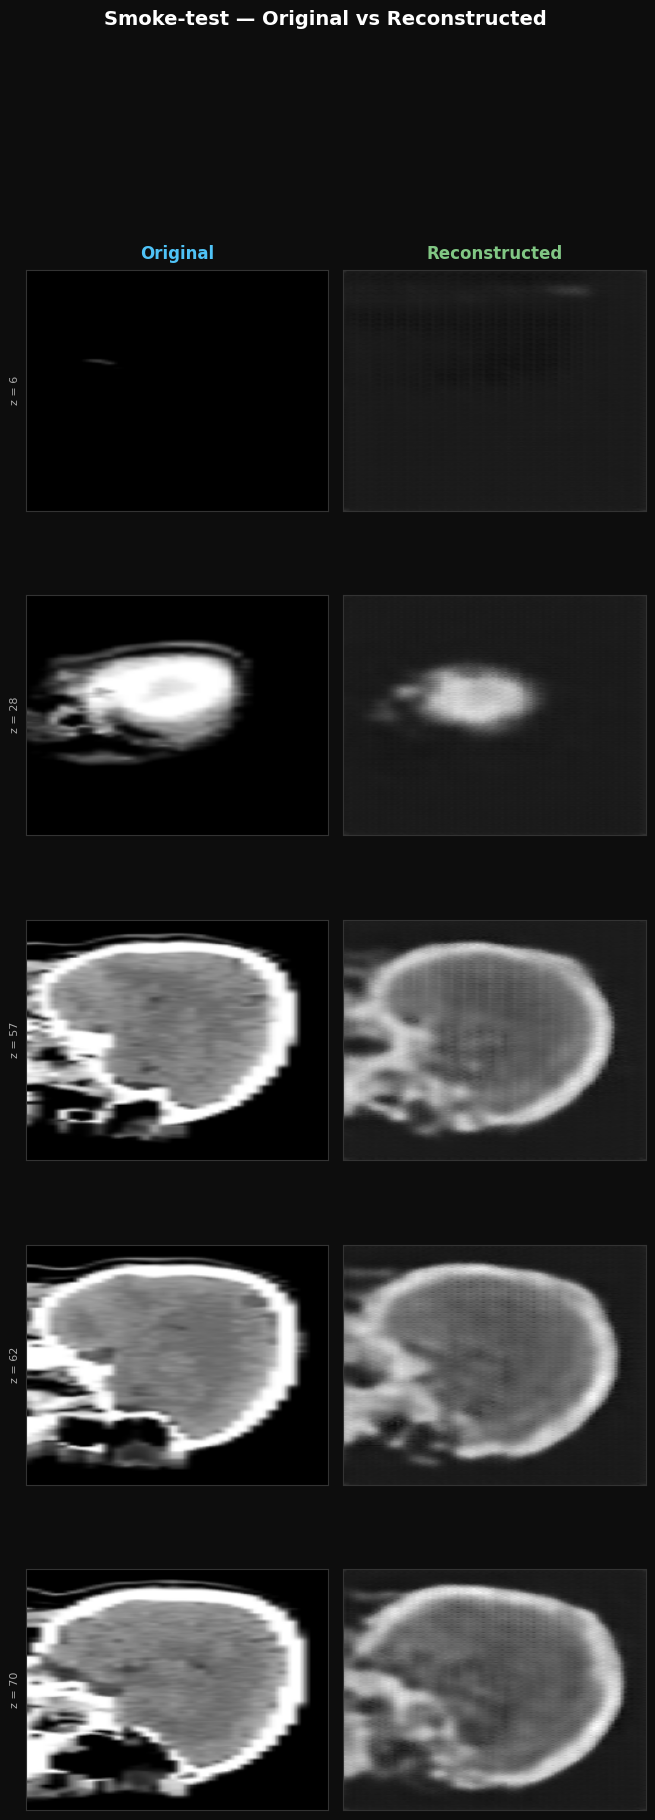

In [14]:
from vis_module import visualize_slices


# ── quick smoke-test ───────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running smoke-test on: {device}")

# Simulate a (B=1, C=1, D=64, H=128, W=128) pair
orig  = torch.rand(1, 1, 64, 128, 128, device=device)
recon = orig + 0.05 * torch.randn_like(orig)   # slight noise

fig = visualize_slices(
    img,
    x_hat,
    n_slices=5,
    suptitle="Smoke-test — Original vs Reconstructed",
    save_path="prelim_results/recons_orig/slice_comparison.png",
    seed=42,
)
print("Done. Figure written to /tmp/slice_comparison.png")




In [12]:
data['im_meta_dict']['filename_or_obj']

['/home/jovyan/imgs/Physionet/physionet_scans/ct_scans/082.nii']

In [15]:
from inference_utils import save_nii

save_nii(x_hat, 'prelim_results/physionet_082_recons.nii.gz')

## Difference

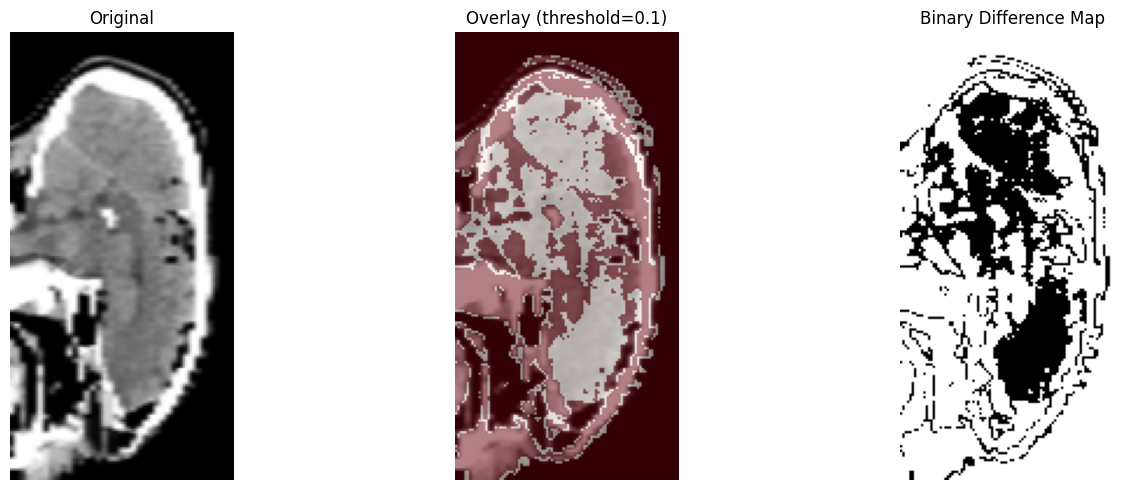

Slice 80 | Differing voxels: 13251 (71.9% of slice)


In [50]:
def plot_difference_map(original, reconstructed, threshold=0.1, slice_idx=None):
    """
    original, reconstructed: tensors of shape (1, 1, D, H, W) or (1, D, H, W) or (D, H, W)
    threshold: difference above this value is marked as 1
    slice_idx: which axial slice to show (defaults to middle)
    """
    # Remove batch and channel dims
    orig = original.squeeze()        # (D, H, W)
    recon = reconstructed.squeeze()  # (D, H, W)

    # Normalize to [0, 1] for comparison
    orig  = (orig  - orig.min())  / (orig.max()  - orig.min())
    recon = (recon - recon.min()) / (recon.max() - recon.min())

    diff = (orig - recon).abs()      # absolute difference
    binary_map = (diff > threshold).float()  # 1 where difference is large

    # Pick middle slice if not specified
    if slice_idx is None:
        slice_idx = orig.shape[0] // 2

    orig_slice   = orig[slice_idx].cpu().numpy()
    binary_slice = binary_map[slice_idx].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(orig_slice, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(orig_slice, cmap='gray')
    axes[1].imshow(binary_slice, cmap='Reds', alpha=0.5)  # overlay
    axes[1].set_title(f'Overlay (threshold={threshold})')
    axes[1].axis('off')

    axes[2].imshow(binary_slice, cmap='gray')
    axes[2].set_title('Binary Difference Map')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Slice {slice_idx} | Differing voxels: {binary_slice.sum():.0f} "
          f"({100 * binary_slice.mean():.1f}% of slice)")

# Usage
plot_difference_map(img_device, x_hat, threshold=0.1, slice_idx=80)